In [3]:
# notebooks/00_messy_starter.ipynb  (one cell)

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

   limit_bal  sex  education  marriage  age  pay_0  pay_2  pay_3  pay_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   pay_5  ...  bill_amt4  bill_amt5  bill_amt6  pay_amt1  pay_amt2  pay_amt3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   pay_amt4  pay_amt5  pay_amt6  default  
0         0         0    

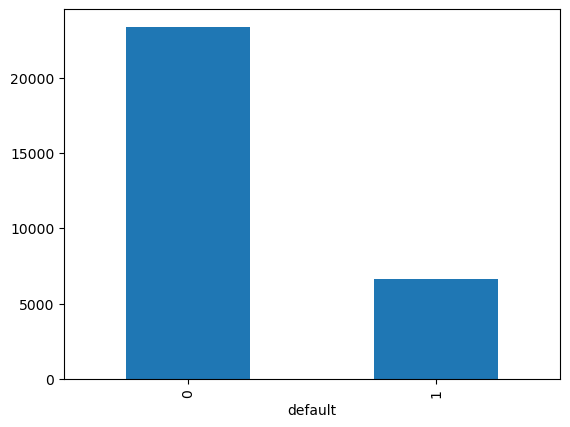

In [12]:
# load
ds = fetch_ucirepo(id=350)

rename_map = {
    row["name"]: row["description"].strip().lower().replace(" ", "_")
    for _, row in ds.variables.iterrows()
    if row["role"] != "ID" and pd.notna(row["description"])
}
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
df = df.rename(columns=rename_map).rename(columns={"default_payment_next_month": "default"})

# quick look
print(df.head())
print(df.shape)
print(df.isnull().sum())

# eda
df["default"].value_counts().plot.bar()
plt.show()

In [14]:
# clean a couple of weird categories
df["education"] = df["education"].replace({0: 4, 5: 4, 6: 4})
df["marriage"] = df["marriage"].replace({0: 3})

# feature engineering — kinda
df["avg_bill"] = df[["bill_amt1","bill_amt2","bill_amt3","bill_amt4","bill_amt5","bill_amt6"]].mean(axis=1)
df["avg_pay"]  = df[["pay_amt1","pay_amt2","pay_amt3","pay_amt4","pay_amt5","pay_amt6"]].mean(axis=1)
df["util"]     = df["avg_bill"] / df["limit_bal"]

# split
X = df.drop(columns=["default"])
y = df["default"]

# OOPS: scaling on full X before split → data leakage
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# model 1
m1 = LogisticRegression(max_iter=1000)
m1.fit(X_train, y_train)
print("LR acc:", accuracy_score(y_test, m1.predict(X_test)))
print("LR auc:", roc_auc_score(y_test, m1.predict_proba(X_test)[:,1]))

# model 2
m2 = RandomForestClassifier(n_estimators=200, random_state=42)
m2.fit(X_train, y_train)
print("RF acc:", accuracy_score(y_test, m2.predict(X_test)))
print("RF auc:", roc_auc_score(y_test, m2.predict_proba(X_test)[:,1]))
print(classification_report(y_test, m2.predict(X_test)))

# save the model... somewhere
import pickle
pickle.dump(m2, open("model.pkl", "wb"))

LR acc: 0.8085
LR auc: 0.7284235324781432
RF acc: 0.8148333333333333
RF auc: 0.763366401631711
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.37      0.47      1313

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.81      0.80      6000

